In this exercise, we will predict the number of applications received
using the other variables in the College data set.

In [23]:
import numpy as np
import pandas as pd
import ISLP
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.cross_decomposition import PLSRegression

(a) Split the data set into a training set and a test set.

In [12]:
df = ISLP.load_data('College')
print(df.describe())
y = df['Apps']
X = pd.get_dummies(df.drop('Apps', axis=1), drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

               Apps        Accept       Enroll   Top10perc   Top25perc  \
count    777.000000    777.000000   777.000000  777.000000  777.000000   
mean    3001.638353   2018.804376   779.972973   27.558559   55.796654   
std     3870.201484   2451.113971   929.176190   17.640364   19.804778   
min       81.000000     72.000000    35.000000    1.000000    9.000000   
25%      776.000000    604.000000   242.000000   15.000000   41.000000   
50%     1558.000000   1110.000000   434.000000   23.000000   54.000000   
75%     3624.000000   2424.000000   902.000000   35.000000   69.000000   
max    48094.000000  26330.000000  6392.000000   96.000000  100.000000   

        F.Undergrad   P.Undergrad      Outstate   Room.Board        Books  \
count    777.000000    777.000000    777.000000   777.000000   777.000000   
mean    3699.907336    855.298584  10440.669241  4357.526384   549.380952   
std     4850.420531   1522.431887   4023.016484  1096.696416   165.105360   
min      139.000000      

(b) Fit a linear model using least squares on the training set, and
report the test error obtained.

In [10]:
# 1. 建立模型並在 Training set 上訓練
lm = LinearRegression()
lm.fit(X_train, y_train)

# 2. 預測 Test set
y_pred = lm.predict(X_test)

# 3. 計算並報告 MSE
mse_ols = mean_squared_error(y_test, y_pred)
print(f"Least Squares Test MSE: {mse_ols:.4f}")

Least Squares Test MSE: 642753.8977


(c) Fit a ridge regression model on the training set, with λ chosen
by cross-validation. Report the test error obtained

In [16]:
# 1. 標準化 (Scale the data)
# 這是最重要的一步，用 Training set 的標準來縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 設定要測試的 lambda (alpha) 範圍
# RidgeCV 會自動用 Cross-Validation (預設留一法 LOOCV) 選最好的 alpha
# 我們給它一個很廣的範圍來選
alphas = [0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas, scoring='neg_mean_squared_error')

# 3. 訓練模型
ridge_cv.fit(X_train_scaled, y_train)

# 4. 預測並計算 Test MSE
y_pred_ridge = ridge_cv.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge Test MSE: {mse_ridge:.4f}")
print(f"Best Alpha (Lambda): {ridge_cv.alpha_}")

Ridge Test MSE: 642765.3963
Best Alpha (Lambda): 0.01


(d) Fit a lasso model on the training set, with λ chosen by cross-
validation. Report the test error obtained, along with the number of non-zero coefficient estimates.

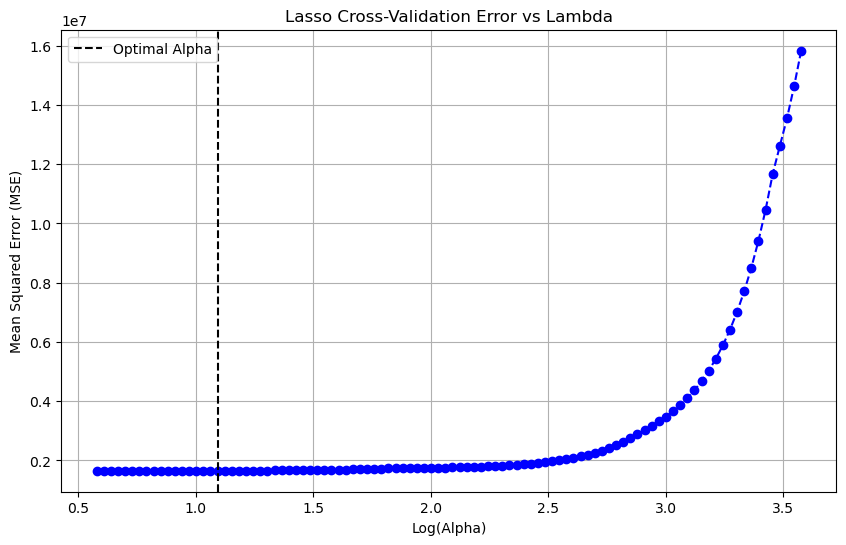

Lasso Test MSE: 659813.5890, Best Alpha: 12.3778762123246
Number of non-zero coefficients: 14


In [19]:
from sklearn.linear_model import LassoCV

# 1. 沿用上面的 scaler 數據
# 2. 使用 LassoCV
lasso = LassoCV(cv=10, random_state=1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# 3. 預測
y_pred_lasso = lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# 3. 畫出 Cross-Validation Error vs Lambda (Alpha)
# LassoCV 會嘗試很多不同的 alpha，我們把它畫出來
alphas = lasso.alphas_
mse_mean = lasso.mse_path_.mean(axis=1) # 算出每次 CV 的平均誤差

plt.figure(figsize=(10, 6))
plt.plot(np.log10(alphas), mse_mean, linestyle='--', marker='o', color='b')
plt.axvline(np.log10(lasso.alpha_), linestyle='--', color='k', label='Optimal Alpha')
plt.xlabel('Log(Alpha)') # 通常用 Log 座標看比較清楚
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Lasso Cross-Validation Error vs Lambda')
plt.legend()
plt.grid(True)
plt.show()

# 4. 計算非零係數 (Non-zero coefficients)
n_nonzero = sum(lasso.coef_ != 0)

print(f"Lasso Test MSE: {mse_lasso:.4f}, Best Alpha: {lasso.alpha_}")
print(f"Number of non-zero coefficients: {n_nonzero}")

(e) Fit a PCR model on the training set, with M chosen by cross-
validation. Report the test error obtained, along with the value
of M selected by cross-validation.

In [22]:
# 1. 尋找最佳的 M (Component 數量)
best_score = float('inf')
best_M = 0
scores = []

# 迴圈測試 M = 1 到 M = 變數總數
# 注意：PCA 也一定要用 scaled 的數據
for m in range(1, X_train_scaled.shape[1] + 1):
    pca = PCA(n_components=m)
    X_train_pca = pca.fit_transform(X_train_scaled)
    
    # 使用 Linear Regression 做 CV
    lr = LinearRegression()
    # cross_val_score 回傳的是負的 MSE (neg_mean_squared_error)，所以要加負號
    mse_cv = -1 * cross_val_score(lr, X_train_pca, y_train, cv=10, scoring='neg_mean_squared_error').mean()
    
    scores.append(mse_cv)
    if mse_cv < best_score:
        best_score = mse_cv
        best_M = m

print(f"Best M for PCR is: {best_M}")

# 2. 用最佳 M 再訓練一次並評估 Test Set
pca_best = PCA(n_components=best_M)
X_train_best_pca = pca_best.fit_transform(X_train_scaled)
X_test_best_pca = pca_best.transform(X_test_scaled)

lr_pcr = LinearRegression()
lr_pcr.fit(X_train_best_pca, y_train)
y_pred_pcr = lr_pcr.predict(X_test_best_pca)
print(f"PCR Test MSE: {mean_squared_error(y_test, y_pred_pcr):.4f}")

Best M for PCR is: 17
PCR Test MSE: 642753.8977


(f) Fit a PLS model on the training set, with M chosen by cross-
validation. Report the test error obtained, along with the value
of M selected by cross-validation.

In [26]:
best_score = float('inf')
best_M_pls = 0

# 1. 尋找最佳 M
for m in range(1, X_train_scaled.shape[1] + 1):
    pls = PLSRegression(n_components=m)
    # PLS 的 CV 寫法跟上面類似
    mse_cv = -1 * cross_val_score(pls, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error').mean()
    
    if mse_cv < best_score:
        best_score = mse_cv
        best_M_pls = m

print(f"Best M for PLS is: {best_M_pls}")

# 2. 用最佳 M 評估 Test Set
pls_best = PLSRegression(n_components=best_M_pls)
pls_best.fit(X_train_scaled, y_train)
y_pred_pls = pls_best.predict(X_test_scaled)
print(f"PLS Test MSE: {mean_squared_error(y_test, y_pred_pls):.4f}")

Best M for PLS is: 17
PLS Test MSE: 642753.8977


(g) Comment on the results obtained. How accurately can we predict the number of college applications received? Is there much
difference among the test errors resulting from these five approaches?

| Model | Test MSE | Hyperparameters / Notes |
| :--- | :--- | :--- |
| **(b) Least Squares (OLS)** | `642,753.90` | Baseline (All 17 predictors) |
| **(c) Ridge Regression** | `642,765.40` | $\lambda = 0.01$ (Very small penalty) |
| **(d) Lasso Regression** | `659,813.59` | $\lambda \approx 12.38$, Non-zero coeffs: 14 |
| **(e) PCR** | `642,753.90` | $M = 17$ (Using all components) |
| **(f) PLS** | `642,753.90` | $M = 17$ (Using all components) |



1.  **Equivalence of OLS, PCR, and PLS:**
    * OLS, PCR, and PLS yielded the **exact same Test MSE**.
    * **Reason:** Both PCR and PLS selected $M=17$ (the total number of predictors) during cross-validation. Mathematically, when the number of components equals the number of predictors ($M=p$), PCR and PLS reduce to standard Least Squares regression.

2.  **Ridge Regression:**
    * Performed almost identically to OLS. The optimal penalty $\lambda$ was very small ($0.01$), meaning the shrinkage effect was negligible.

3.  **Lasso Regression:**
    * Resulted in the highest MSE. This suggests that forcing variable selection (reducing the model to 14 predictors) led to a slight loss of information compared to using the full set of predictors.